In [2]:
import xarray as xr

ds = xr.open_dataset('../data/woa23_all_o00_01.nc', decode_times=False)
print(ds)

<xarray.Dataset> Size: 291MB
Dimensions:             (lat: 180, nbounds: 2, lon: 360, depth: 102, time: 1)
Coordinates:
  * lat                 (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                 (lon) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * depth               (depth) float32 408B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * time                (time) float32 4B 3.894e+03
Dimensions without coordinates: nbounds
Data variables: (12/14)
    crs                 int32 4B ...
    lat_bnds            (lat, nbounds) float32 1kB ...
    lon_bnds            (lon, nbounds) float32 3kB ...
    depth_bnds          (depth, nbounds) float32 816B ...
    climatology_bounds  (time, nbounds) float32 8B ...
    o_an                (time, depth, lat, lon) float32 26MB ...
    ...                  ...
    o_sd                (time, depth, lat, lon) float32 26MB ...
    o_se                (time, depth, lat, lon) float32 26MB ...
    o_oa                (time, depth, lat, 

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# extract the main oxygen variable, surface level only (depth index 0)
oxygen = ds['o_an'].isel(time=0, depth=0)

# crop to Gulf of Mexico
gulf = oxygen.sel(lat=slice(18, 31), lon=slice(-98, -81))

print(gulf)
print(f"\nShape: {gulf.shape}")
print(f"Min oxygen: {float(gulf.min()):.2f}")
print(f"Max oxygen: {float(gulf.max()):.2f}")

<xarray.DataArray 'o_an' (lat: 13, lon: 17)> Size: 884B
[221 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 52B 18.5 19.5 20.5 21.5 22.5 ... 27.5 28.5 29.5 30.5
  * lon      (lon) float32 68B -97.5 -96.5 -95.5 -94.5 ... -83.5 -82.5 -81.5
    depth    float32 4B 0.0
    time     float32 4B 3.894e+03
Attributes:
    standard_name:  moles_of_oxygen_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_oxygen_per_...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

Shape: (13, 17)
Min oxygen: 191.53
Max oxygen: 218.27


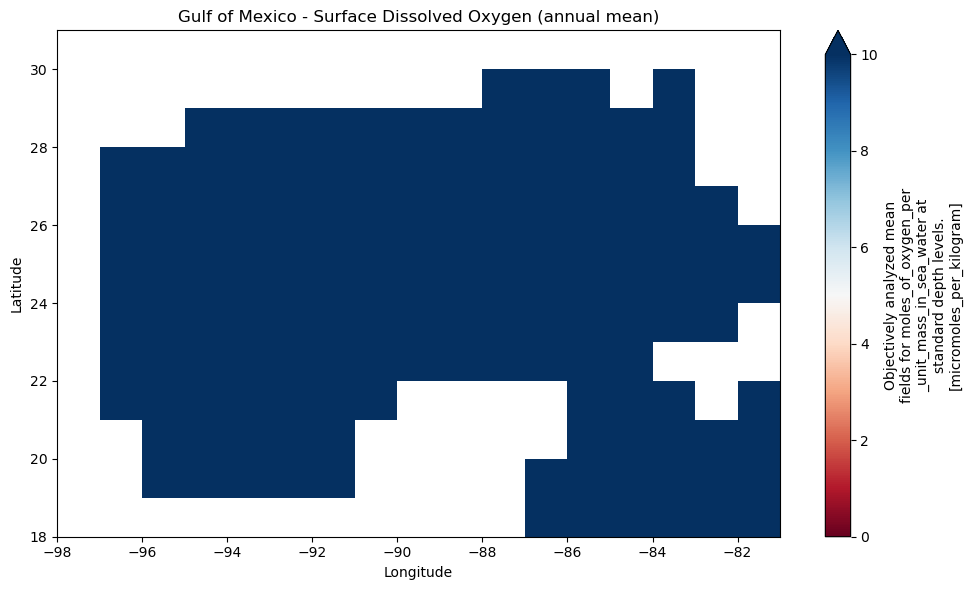

In [4]:
plt.figure(figsize=(10, 6))
gulf.plot(cmap='RdBu', vmin=0, vmax=10)
plt.title('Gulf of Mexico - Surface Dissolved Oxygen (annual mean)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('../outputs/gulf_oxygen_surface.png', dpi=150)
plt.show()

In [5]:
# check oxygen at different depths
for i in [0, 1, 2, 5, 10, 20]:
    depth_val = float(ds['o_an'].depth[i])
    o2 = ds['o_an'].isel(time=0, depth=i).sel(lat=slice(18, 31), lon=slice(-98, -81))
    min_o2 = float(o2.min())
    print(f"Depth index {i:2d} ({depth_val:6.1f}m): min O2 = {min_o2:.1f} µmol/kg  {'<-- HYPOXIC' if min_o2 < 63 else ''}")

Depth index  0 (   0.0m): min O2 = 191.5 µmol/kg  
Depth index  1 (   5.0m): min O2 = 192.6 µmol/kg  
Depth index  2 (  10.0m): min O2 = 193.0 µmol/kg  
Depth index  5 (  25.0m): min O2 = 192.2 µmol/kg  
Depth index 10 (  50.0m): min O2 = 186.9 µmol/kg  
Depth index 20 ( 100.0m): min O2 = 146.4 µmol/kg  


In [6]:
for i in range(20, 50):
    depth_val = float(ds['o_an'].depth[i])
    o2 = ds['o_an'].isel(time=0, depth=i).sel(lat=slice(18, 31), lon=slice(-98, -81))
    min_o2 = float(o2.min())
    print(f"Depth index {i:2d} ({depth_val:6.1f}m): min O2 = {min_o2:.1f} µmol/kg  {'<-- HYPOXIC' if min_o2 < 63 else ''}")

Depth index 20 ( 100.0m): min O2 = 146.4 µmol/kg  
Depth index 21 ( 125.0m): min O2 = 123.5 µmol/kg  
Depth index 22 ( 150.0m): min O2 = 122.0 µmol/kg  
Depth index 23 ( 175.0m): min O2 = 117.2 µmol/kg  
Depth index 24 ( 200.0m): min O2 = 112.6 µmol/kg  
Depth index 25 ( 225.0m): min O2 = 109.3 µmol/kg  
Depth index 26 ( 250.0m): min O2 = 104.8 µmol/kg  
Depth index 27 ( 275.0m): min O2 = 103.8 µmol/kg  
Depth index 28 ( 300.0m): min O2 = 103.5 µmol/kg  
Depth index 29 ( 325.0m): min O2 = 104.7 µmol/kg  
Depth index 30 ( 350.0m): min O2 = 103.3 µmol/kg  
Depth index 31 ( 375.0m): min O2 = 103.0 µmol/kg  
Depth index 32 ( 400.0m): min O2 = 104.0 µmol/kg  
Depth index 33 ( 425.0m): min O2 = 105.9 µmol/kg  
Depth index 34 ( 450.0m): min O2 = 106.7 µmol/kg  
Depth index 35 ( 475.0m): min O2 = 106.9 µmol/kg  
Depth index 36 ( 500.0m): min O2 = 109.4 µmol/kg  
Depth index 37 ( 550.0m): min O2 = 110.9 µmol/kg  
Depth index 38 ( 600.0m): min O2 = 115.5 µmol/kg  
Depth index 39 ( 650.0m): min O

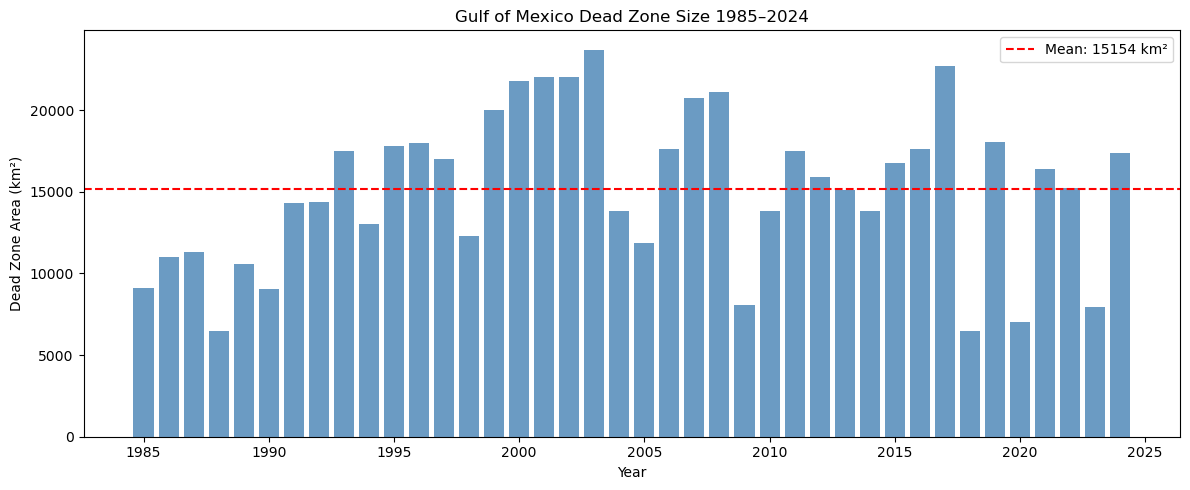

              year      area_km2
count    40.000000     40.000000
mean   2004.500000  15153.650000
std      11.690452   4785.848003
min    1985.000000   6480.000000
25%    1994.750000  11720.000000
50%    2004.500000  15570.000000
75%    2014.250000  17850.000000
max    2024.000000  23700.000000


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Annual Gulf of Mexico dead zone size (km²) from LUMCON/NOAA cruises 1985–2024
# Source: gulfhypoxia.net / NOAA NCCOS
data = {
    'year': [1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,
             1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,
             2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,
             2015,2016,2017,2018,2019,2020,2021,2022,2023,2024],
    'area_km2': [9100,11000,11300,6500,10600,9030,14300,14400,17500,13000,
                 17800,18000,17000,12300,20000,21756,22000,22000,23700,13840,
                 11860,17640,20720,21080,8040,13800,17520,15920,15120,13800,
                 16770,17600,22720,6480,18050,7030,16380,15220,7920,17350]
}

df = pd.DataFrame(data)

plt.figure(figsize=(12, 5))
plt.bar(df['year'], df['area_km2'], color='steelblue', alpha=0.8)
plt.axhline(df['area_km2'].mean(), color='red', linestyle='--', label=f"Mean: {df['area_km2'].mean():.0f} km²")
plt.xlabel('Year')
plt.ylabel('Dead Zone Area (km²)')
plt.title('Gulf of Mexico Dead Zone Size 1985–2024')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/deadzone_timeseries.png', dpi=150)
plt.show()

print(df.describe())